# 4. Ground and height

Classify ground returns, interpolate a terrain model, and turn elevations into
heights above ground.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

DATA = Path("data")          # the Litchfield tile, cut by make_litch_subset.py
plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
from sylva import canopy, filters, ground

cloud = filters.voxel_downsample(sylva.read(DATA / "litch_tile.laz"), 0.05)

## Ground classification

Two filters: the cloth simulation filter (CSF, Zhang et al. 2016) drapes a
cloth over the inverted cloud; the progressive morphological filter (PMF,
Zhang et al. 2003) opens a minimum surface with growing windows.

The tile's own `classification` came from PMF (see `make_litch_subset.py`), so
compare the two directly. On this savanna tile CSF leaves the terrain several
metres too high in about 8 % of cells -- the cloth hangs on the dense grass and
shrub layer -- while PMF's opening removes it. Which filter wins is a property
of the stand, so check a profile before trusting either.

In [2]:
csf = ground.ground_mask(ground.classify_ground_csf(cloud))
pmf = ground.ground_mask(ground.classify_ground_pmf(cloud))
for name, m in (("CSF", csf), ("PMF", pmf)):
    print(f"{name}: {m.sum():>8,} ground points ({m.mean():.1%}); "
          f"highest ground point {cloud.z[m].max():5.2f} m")

dtm_csf = ground.make_dtm(cloud.with_attrs(classification=np.where(csf, 2, 1).astype("uint8")), 0.5, bounds=(0, 0, 20, 20))
dtm = ground.make_dtm(cloud.with_attrs(classification=np.where(pmf, 2, 1).astype("uint8")), 0.5, bounds=(0, 0, 20, 20))
diff = dtm_csf.data - dtm.data
print(f"CSF above PMF by more than 0.5 m in {np.mean(diff > 0.5):.1%} of cells, "
      f"95th percentile {np.nanpercentile(diff, 95):.1f} m")

CSF:  261,931 ground points (17.4%); highest ground point 15.72 m
PMF:  283,533 ground points (18.8%); highest ground point  0.48 m
CSF above PMF by more than 0.5 m in 7.6% of cells, 95th percentile 5.1 m


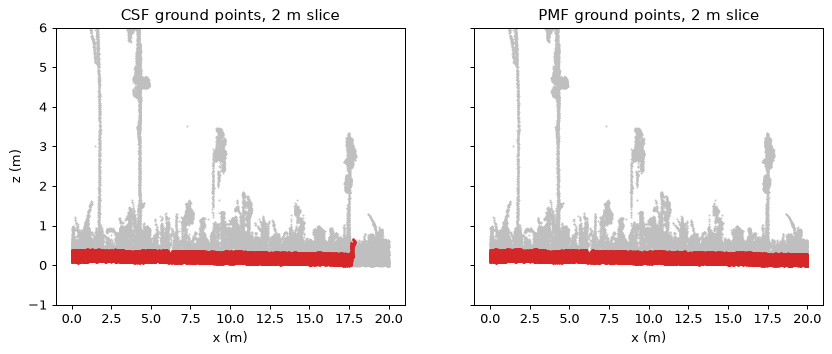

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
slab = (cloud.y > 9) & (cloud.y < 11)
for a, m, name in ((ax[0], csf, "CSF"), (ax[1], pmf, "PMF")):
    a.scatter(cloud.x[slab], cloud.z[slab], s=0.3, c="0.75")
    a.scatter(cloud.x[slab & m], cloud.z[slab & m], s=1.0, c="C3")
    a.set(title=f"{name} ground points, 2 m slice", xlabel="x (m)", ylim=(-1, 6))
ax[0].set_ylabel("z (m)");

## DTM, heights and CHM

In [4]:
cloud = ground.normalize_height(cloud, dtm)          # adds the 'height' attribute
flat = ground.flatten(cloud, dtm)                    # or replace z itself
chm = ground.make_chm(cloud, resolution=0.5)
print("terrain relief across the tile:", round(float(np.nanmax(dtm.data) - np.nanmin(dtm.data)), 2), "m")
print("canopy height p99:", round(float(np.percentile(cloud.attrs["height"], 99)), 1), "m,",
      "max", round(float(cloud.attrs["height"].max()), 1), "m")
print("canopy cover above 2 m:", round(float(canopy.canopy_cover(chm.data, 2.0)), 3))

terrain relief across the tile: 0.34 m
canopy height p99: 18.7 m, max 20.0 m
canopy cover above 2 m: 0.683


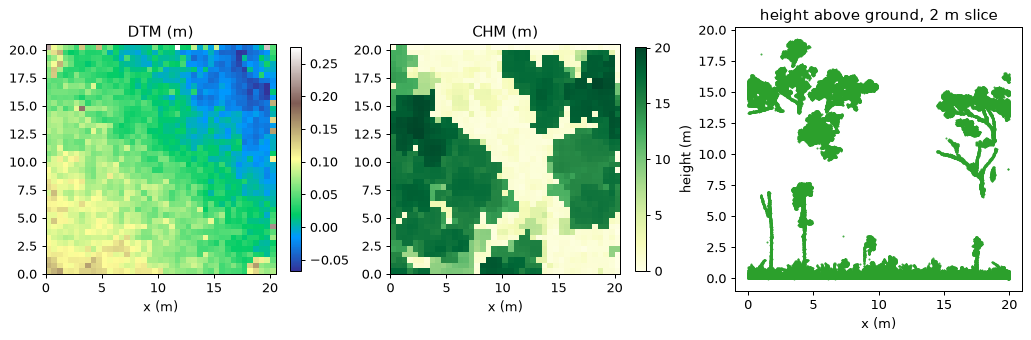

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for a, r, title, cmap in ((ax[0], dtm, "DTM (m)", "terrain"), (ax[1], chm, "CHM (m)", "YlGn")):
    im = a.imshow(r.data, origin="lower", extent=(r.xmin, r.xmax, r.ymin, r.ymax), cmap=cmap)
    a.set(title=title, xlabel="x (m)"); fig.colorbar(im, ax=a, shrink=0.85)
ax[2].scatter(cloud.x[slab], cloud.attrs["height"][slab], s=0.3, c="C2")
ax[2].set(title="height above ground, 2 m slice", xlabel="x (m)", ylabel="height (m)");

Rasters export to an ESRI ASCII grid, or to GeoTIFF with
`dtm.to_geotiff("dtm.tif", crs="EPSG:28352")` when `rasterio` is installed
(`pip install sylva-rs[geotiff]`). Pass the same `bounds` on every date so a
time series lines up.

In [6]:
chm.to_ascii_grid("chm.asc")
sylva.write(cloud, "tile_normalized.laz")       # keeps 'height' as an extra-bytes dimension
print(sorted(sylva.read("tile_normalized.laz").attrs))

['classification', 'gps_time', 'height', 'intensity', 'number_of_returns', 'point_source_id', 'return_number', 'scan_angle', 'user_data']
